### Изучение рынка заведений общественного питания Москвы
### Цель и задачи проекта
### Цель:

Провести исследовательский анализ даных заведений общественного питания Москвы для выбора подходящего инвесторам места для открытия собсвенного бизнеса.
#### Задачи:

1. Загрузить данные и познакомиться с ними, сделать первые выводы о качестве данных
2. Предобработка данных с целью подготовки к исследовательскому анализу
3. Исследовательский анализ данных
4. Итоговые выводы и рекомендации для заказчика
#### Описание данных
Файл /datasets/rest_info.csv содержит информацию о заведениях общественного питания:
* name — название заведения;
* address — адрес заведения;
* district — административный район, в котором находится заведение, например Центральный административный округ;
* category — категория заведения, например «кафе», «пиццерия» или «кофейня»;
* hours — информация о днях и часах работы;
* rating — рейтинг заведения по оценкам пользователей в Яндекс Картах (высшая оценка — 5.0);
* chain — число, выраженное 0 или 1, которое показывает, является ли заведение сетевым (для маленьких сетей могут встречаться ошибки):
0 — заведение не является сетевым;
1 — заведение является сетевым.
* seats — количество посадочных мест.


Файл /datasets/rest_price.csv содержит информацию о среднем чеке в заведениях общественного питания:
* price — категория цен в заведении, например «средние», «ниже среднего», «выше среднего» и так далее;
* avg_bill — строка, которая хранит среднюю стоимость заказа в виде диапазона, например:
«Средний счёт: 1000–1500 ₽»;
«Цена чашки капучино: 130–220 ₽»;
«Цена бокала пива: 400–600 ₽».
и так далее;
* middle_avg_bill — число с оценкой среднего чека, которое указано только для значений из столбца avg_bill, начинающихся с подстроки «Средний счёт»:
Если в строке указан ценовой диапазон из двух значений, в столбец войдёт медиана этих двух значений.
Если в строке указано одно число — цена без диапазона, то в столбец войдёт это число.
Если значения нет или оно не начинается с подстроки «Средний счёт», то в столбец ничего не войдёт.
* middle_coffee_cup — число с оценкой одной чашки капучино, которое указано только для значений из столбца avg_bill, начинающихся с подстроки «Цена одной чашки капучино»:
Если в строке указан ценовой диапазон из двух значений, в столбец войдёт медиана этих двух значений.
Если в строке указано одно число — цена без диапазона, то в столбец войдёт это число.
Если значения нет или оно не начинается с подстроки «Цена одной чашки капучино», то в столбец ничего не войдёт.

## 1. Загрузка данных и знакомство с ними
Начнём с загрузки библиотек и данных о заведениях общественного питания Москвы. Путь к файлам: /datasets/rest_info.csv и /datasets/rest_price.csv.  Будем использовать pandas и библиотеки визуализации данных matplotlib и seaborn, а также phik для построения матрицы корреляции. Данные датасетов сохраним в двух переменных: `info_df` и `price_df`.

In [1]:
# Импортируем библиотеки
import pandas as pd
import numpy as np

# Загружаем библиотеки для визуализации данных
import matplotlib.pyplot as plt
import seaborn as sns

# Загружаем библиотеку для расчёта коэффициента корреляции phi_k
from phik import phik_matrix


 Выгружаем данные в переменные info_df и price_df

In [2]:

info_df = pd.read_csv('https://code.s3.yandex.net//datasets/rest_info.csv')
price_df = pd.read_csv('https://code.s3.yandex.net//datasets/rest_price.csv')

Познакомимся с данными датасета `rest_info.csv` — выведем первые строки методом `head()`, а информацию о датафрейме методом `info()`:

In [3]:
# Выводим первые строки датафрейма на экран
info_df.head()

,id,name,category,address,district,hours,rating,chain,seats
0,0c3e3439a8c64ea5bf6ecd6ca6ae19f0,WoWфли,кафе,"Москва, улица Дыбенко, 7/1",Северный административный округ,"ежедневно, 10:00–22:00",5.0,0,NaN
1,045780ada3474c57a2112e505d74b633,Четыре комнаты,ресторан,"Москва, улица Дыбенко, 36, корп. 1",Северный административный округ,"ежедневно, 10:00–22:00",4.5,0,4.0
2,1070b6b59144425896c65889347fcff6,Хазри,кафе,"Москва, Клязьминская улица, 15",Северный административный округ,"пн-чт 11:00–02:00; пт,сб 11:00–05:00; вс 11:00...",4.6,0,45.0
3,03ac7cd772104f65b58b349dc59f03ee,Dormouse Coffee Shop,кофейня,"Москва, улица Маршала Федоренко, 12",Северный административный округ,"ежедневно, 09:00–22:00",5.0,0,NaN
4,a163aada139c4c7f87b0b1c0b466a50f,Иль Марко,пиццерия,"Москва, Правобережная улица, 1Б",Северный административный округ,"ежедневно, 10:00–22:00",5.0,1,148.0


In [4]:
# Выводим информацию о датафрейме
info_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8406 entries, 0 to 8405
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        8406 non-null   object 
 1   name      8406 non-null   object 
 2   category  8406 non-null   object 
 3   address   8406 non-null   object 
 4   district  8406 non-null   object 
 5   hours     7870 non-null   object 
 6   rating    8406 non-null   float64
 7   chain     8406 non-null   int64  
 8   seats     4795 non-null   float64
dtypes: float64(2), int64(1), object(6)
memory usage: 591.2+ KB


Датасет `rest_info.csv` содержит 9 столбцов и 8406 строк, в которых представлена информация о заведениях общественного питания города Москва.

После первичного анализа данных можно сделать следующие выводы:
- Названия столбцов имеют один вид, понятны по значению и не требуют обработки.
- Представленные данные содержат строковые и числовые значения и хранятся в типах данных `object`, `int64` или `float64`. Значения в столбцах `id`, `name`, `category`, `address`, `district` и `hours` представлены строковыви данными и имеют в себе как текст, так и цифры. Значения в столбцах `rating`, `seats` числовые данные. Столбец `chain`имеет атрибуты признака и содержит значения 1 или 0 — размерность этих данных можно оптимизировать.
- Пропуски содержатся в столбцах `hours`- информация о времени работы и`seats`- количестве посадочных мест. 
- Судя по первому знакомству с данными, значения в столбцах соответствуют своему описанию.

Теперь познакомимся с данными датасета `rest_price.csv`.

In [5]:
# Выводим первые строки датафрейма на экран
price_df.head()

,id,price,avg_bill,middle_avg_bill,middle_coffee_cup
0,045780ada3474c57a2112e505d74b633,выше среднего,Средний счёт:1500–1600 ₽,1550.0,NaN
1,1070b6b59144425896c65889347fcff6,средние,Средний счёт:от 1000 ₽,1000.0,NaN
2,03ac7cd772104f65b58b349dc59f03ee,NaN,Цена чашки капучино:155–185 ₽,NaN,170.0
3,a163aada139c4c7f87b0b1c0b466a50f,средние,Средний счёт:400–600 ₽,500.0,NaN
4,8a343546b24e4a499ad96eb7d0797a8a,средние,NaN,NaN,NaN


In [6]:
# Выводим информацию о датафрейме
price_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4058 entries, 0 to 4057
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 4058 non-null   object 
 1   price              3315 non-null   object 
 2   avg_bill           3816 non-null   object 
 3   middle_avg_bill    3149 non-null   float64
 4   middle_coffee_cup  535 non-null    float64
dtypes: float64(2), object(3)
memory usage: 158.6+ KB


Датасет `price_info.csv` содержит 5 столбцов и 4058 строк, в которых представлена информация о среднем чеке в заведениях общественного питания.

После первичного анализа данных можно сделать следующие выводы:
- Названия столбцов имеют нужный вид, понятны по значению и не требуют обработки.
- Представленные данные содержат строковые и числовые значения и хранятся в типах данных `object` или `float64`. Значения в столбцах `id`, `price`, `avg_bill` представлены строковыми данными и имеют в себе как текст, так и цифры. Значения в столбцах `middle_avg_bill`, `middle_coffee_cup` числовые данные. 
- Пропуски содержатся во всех столбцах, кроме  `id`, что говорит о не очень хорошем качестве данных. Наиболее важными данными будут данные о средней цене из столбца `avg_bill`.
- Судя по первому знакомству с данными, значения в столбцах соответствуют своему описанию.
Первичное знакомство с данными показало, что названия столбцов соответствуют установленой форме и содежание соответствует описанию. Тем не менее данные имеют пропуски с которыми нужно поработать.

#### Подготовка единого датафрейма

Задача проекта предполагает анализ ценообразования в различных районах города, поэтому можно соединить данные о заведениях `info_df`, со средними ценами на товар из таблицы `price_df`.

Каждая строка в этих датафреймах — это информация о заведении, его расположении и ценах в этих заведениях, поэтому такие данные удобно соединить в один датафрейм, который можно использовать для поиска закономерностей в данных. Соединять данные будем по идентификатору заведения. При соединении оставим все данные о заведениях, даже если нет данных о ценах. 

Соединим данные, используя значение параметра `how` — `'left'`. Это позволит оставить все данные по заведениям.

In [7]:
# Соединяем данные в единый датафрейм df
df = info_df.merge(price_df, how='left', on='id')

In [8]:
# Выводим информацию о датафрейме
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8406 entries, 0 to 8405
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 8406 non-null   object 
 1   name               8406 non-null   object 
 2   category           8406 non-null   object 
 3   address            8406 non-null   object 
 4   district           8406 non-null   object 
 5   hours              7870 non-null   object 
 6   rating             8406 non-null   float64
 7   chain              8406 non-null   int64  
 8   seats              4795 non-null   float64
 9   price              3315 non-null   object 
 10  avg_bill           3816 non-null   object 
 11  middle_avg_bill    3149 non-null   float64
 12  middle_coffee_cup  535 non-null    float64
dtypes: float64(4), int64(1), object(8)
memory usage: 853.9+ KB


In [9]:
# Выводим первые строки датафрейма
df.head(25)

,id,name,category,address,district,hours,rating,chain,seats,price,avg_bill,middle_avg_bill,middle_coffee_cup
0,0c3e3439a8c64ea5bf6ecd6ca6ae19f0,WoWфли,кафе,"Москва, улица Дыбенко, 7/1",Северный административный округ,"ежедневно, 10:00–22:00",5.0,0,NaN,NaN,NaN,NaN,NaN
1,045780ada3474c57a2112e505d74b633,Четыре комнаты,ресторан,"Москва, улица Дыбенко, 36, корп. 1",Северный административный округ,"ежедневно, 10:00–22:00",4.5,0,4.0,выше среднего,Средний счёт:1500–1600 ₽,1550.0,NaN
2,1070b6b59144425896c65889347fcff6,Хазри,кафе,"Москва, Клязьминская улица, 15",Северный административный округ,"пн-чт 11:00–02:00; пт,сб 11:00–05:00; вс 11:00...",4.6,0,45.0,средние,Средний счёт:от 1000 ₽,1000.0,NaN
3,03ac7cd772104f65b58b349dc59f03ee,Dormouse Coffee Shop,кофейня,"Москва, улица Маршала Федоренко, 12",Северный административный округ,"ежедневно, 09:00–22:00",5.0,0,NaN,NaN,Цена чашки капучино:155–185 ₽,NaN,170.0
4,a163aada139c4c7f87b0b1c0b466a50f,Иль Марко,пиццерия,"Москва, Правобережная улица, 1Б",Северный административный округ,"ежедневно, 10:00–22:00",5.0,1,148.0,средние,Средний счёт:400–600 ₽,500.0,NaN
5,8a343546b24e4a499ad96eb7d0797a8a,Sergio Pizza,пиццерия,"Москва, Ижорская улица, вл8Б",Северный административный округ,"ежедневно, 10:00–23:00",4.6,0,NaN,средние,NaN,NaN,NaN
6,96ebceb1a09e4e3191133b9fe0379a64,Огни города,"бар,паб","Москва, Клязьминская улица, 9, стр. 3",Северный административный округ,пн 15:00–04:00; вт-вс 15:00–05:00,4.4,0,45.0,средние,Средний счёт:199 ₽,199.0,NaN
7,0243288b78024af090b8e947842c969c,Mr. Уголёк,быстрое питание,"Москва, Клязьминская улица, 9, стр. 3",Северный административный округ,"пн-чт 10:00–22:00; пт,сб 10:00–23:00; вс 10:00...",4.7,0,45.0,средние,Средний счёт:200–300 ₽,250.0,NaN
8,36aeb0ffa69c48fdb0021549520deb10,Donna Maria,ресторан,"Москва, Дмитровское шоссе, 107, корп. 4",Северный административный округ,"ежедневно, 10:00–22:00",4.8,0,79.0,средние,Средний счёт:от 500 ₽,500.0,NaN
9,487167877eb04288bc90d4fa80646fc2,Готика,кафе,"Москва, Ангарская улица, 39",Северный административный округ,"ежедневно, 12:00–00:00",4.3,0,65.0,средние,Средний счёт:1000–1200 ₽,1100.0,NaN


Данные соединились с сохранением информации по всем заведениям общественного питания.

## 2. Предобработка данных
### 2.1. Оптимизируем типы данных

В данных заведений понадобится только провести оптимизацию целочисленных данных в столбце `chain`.

Для оптимизации будем использовать метод `pd.to_numeric` с аргументом `downcast='integer'`:

In [10]:
df['chain'] = pd.to_numeric(df['chain'], downcast='integer')

In [11]:
# Проверим типы данных в датафрейме df с помощью атрибута dtypes
df.dtypes

id                    object
name                  object
category              object
address               object
district              object
hours                 object
rating               float64
chain                   int8
seats                float64
price                 object
avg_bill              object
middle_avg_bill      float64
middle_coffee_cup    float64
dtype: object

### 2.2. Проверяем наличие пропусков в данных

При первичном анализе мы обнаружили пропуски в столбцах датафрейма. Узнаем абсолютное и относительное количество пропусков в столбцах объединенного датафрейма.

In [12]:
# Применяем метод isna() к датафрейму df
df.isna().sum().sort_values(ascending=False)

middle_coffee_cup    7871
middle_avg_bill      5257
price                5091
avg_bill             4590
seats                3611
hours                 536
district                0
category                0
name                    0
id                      0
address                 0
chain                   0
rating                  0
dtype: int64

In [13]:
# Подсчитываем долю строк с пропусками
df.isna().sum() / df.shape[0]

id                   0.000000
name                 0.000000
category             0.000000
address              0.000000
district             0.000000
hours                0.063764
rating               0.000000
chain                0.000000
seats                0.429574
price                0.605639
avg_bill             0.546039
middle_avg_bill      0.625387
middle_coffee_cup    0.936355
dtype: float64

В датафрейме `df` обнаружено:
- 536 пропусков в столбце `hours` — это 6 % данных. Это информация о времени работы. Количество пропусков небольшое, их можно просто удалить.
- 3611 пропусков в столбце `seats`- это 43 % данных. В нем содержится информация о количестве посадочных мест. 
Пропуски в этом столбце могут быть вызваны:
- Не занесены данные в сервисе Яндекс Бизнес. 
- При обработке данных произошёл технический сбой. Технические ошибки могут привести к пропускам в данных, включая случаи, когда количество мест не было записано. 
- Возможно количество пропусков связано стипом заведения, в некоторых типах заведений , например "еда на вынос" или "булочная" просто нет посадочных мест. Можно проверить эту гипотезу, если проанализировать значения в столбцах `category` и`seats` в строках с пропусками. 
- 5091 пропусков в столбце `price`- это 60 % данных. 
Возможные причины пропусков:
- Не занесены данные в сервисе Яндекс Бизнес.
- Возможно некоторые заведения не имеют четкого распределения цены на категории, оставим как есть.
- 4590 пропусков в столбце `avg_bill`, в котором хранится средняя стоимость заказа в виде диапазона значений - это 55 % данных. Оставим данные без изменения, так как они не участвуют в дальнейшем анализе.
- 5257 пропусков в столбце `middle_avg_bill` что составляет 63% от общего количества строк. В нем храниться информация о среднем чеке. Причина пропусков:
- основная причина это  зависимость от предыдущего столбца `avg_bill`, в котором 4590 пропусков, кроме этого в него попадают данные только с подстрокой "Средний счет" из столбца `avg_bill`.
-7871 пропусков в столбце `middle_coffee_cup`, что составляет 94 % пропусков. Причина в том, что сдесь данные только по средней цене кофе, и только из заполненых ячеек `avg_bill`. Этоти данные не будут участвовать в анализе, поэтому оставим их без изменения.



Проверка гипотезы зависимости пропусков в столбце `seats` в зависимости от категории заведения

In [14]:
#  Количество уникальных значений
unique_count = df['category'].nunique()
print(f"Количество уникальных категорий: {unique_count}")

#  Список всех уникальных значений
unique_categories = df['category'].unique()
print(f"\nУникальные категории:")
for cat in unique_categories:
    print(f"  - {cat}")

Количество уникальных категорий: 8

Уникальные категории:
  - кафе
  - ресторан
  - кофейня
  - пиццерия
  - бар,паб
  - быстрое питание
  - булочная
  - столовая


In [15]:
# Получаем уникальные категории
categories = df['category'].dropna().unique()

# Проходим по каждой категории
for category in categories:
    # Фильтруем данные по категории
    category_df = df[df['category'] == category]
    
    # Количество заведений
    total = len(category_df)
    
    # Количество пропусков в seats
    missing = category_df['seats'].isna().sum()
    
    # Процент пропусков
    percent = (missing / total) * 100

    # Выводим информацию
    print(f"Категория: {category}")
    print(f"  - Всего заведений: {total}")
    print(f"  - Пропуски в seats: {missing} ({percent:.1f}%)")

Категория: кафе
  - Всего заведений: 2378
  - Пропуски в seats: 1160 (48.8%)
Категория: ресторан
  - Всего заведений: 2043
  - Пропуски в seats: 773 (37.8%)
Категория: кофейня
  - Всего заведений: 1413
  - Пропуски в seats: 662 (46.9%)
Категория: пиццерия
  - Всего заведений: 633
  - Пропуски в seats: 206 (32.5%)
Категория: бар,паб
  - Всего заведений: 765
  - Пропуски в seats: 297 (38.8%)
Категория: быстрое питание
  - Всего заведений: 603
  - Пропуски в seats: 254 (42.1%)
Категория: булочная
  - Всего заведений: 256
  - Пропуски в seats: 108 (42.2%)
Категория: столовая
  - Всего заведений: 315
  - Пропуски в seats: 151 (47.9%)


Из проведенного исследования видим, что наша гипотеза не подтвердилась и количество мест практически не зависит от типа заведения. Значить это скорее всего пропуски связанные с отсутсвием информации в сервисе Яндекс Бизнес или техническим сбоем.

Проверим пропуски в столбце `price` и заменим их на "цена не определена". 

In [16]:
# Количество уникальных значений
unique_count = df['price'].nunique()
print(f"Количество уникальных категорий: {unique_count}")

#  Список всех уникальных значений
unique_price = df['price'].unique()
print(f"\nУникальные категории:")
for cat in unique_price:
    print(f"  - {cat}")

Количество уникальных категорий: 4

Уникальные категории:
  - nan
  - выше среднего
  - средние
  - высокие
  - низкие


In [17]:

# Заполняем имеющиеся пропуски
df['price'] = df['price'].fillna('цена не определена')

# Проверяем результат
print("Результаты заполнения:")

print("Статистика по столбцу price после заполнения:")
print(df['price'].value_counts())
print(f"\nКоличество пропусков: {df['price'].isna().sum()}")


Результаты заполнения:
Статистика по столбцу price после заполнения:
price
цена не определена    5091
средние               2117
выше среднего          564
высокие                478
низкие                 156
Name: count, dtype: int64

Количество пропусков: 0


В результате проделанной работы пропуски заменены на значение "цена не определена".

### 2.3. Явные и неявные дубликаты в данных

Проверим данные на наличие явных и неявных дубликатов. Начнём с полных дубликатов:

In [18]:
# Проверяем полные дубликаты в объединенном датафрейме df
df.duplicated().sum()

np.int64(0)

В датафрейме нет полных дубликатов. Проверим неявные дубликаты — значения по `id` заведений должны быть уникальными и указывать на отдельное заведение питания.

In [19]:
# Проверяем неявные дубликаты в датафрейме df
df.duplicated(subset='id').sum()

np.int64(0)

В этом случае все хорошо, дубликатов нет.

In [20]:
# Проверяем неявные дубликаты в датафрейме df
df.duplicated(subset='name').sum()

np.int64(2792)

А вот в названии дубликаты есть, нужно проанализировать причину появления дубликатов, возможно это названия сетевых заведений.

In [21]:

# Анализируем дубликаты

# Общее количество дубликатов 
total_duplicates = df.duplicated(subset=['name']).sum()
print(f"Всего записей с дублирующимися названиями: {total_duplicates}")
print(f"Процент от общего числа: {total_duplicates/len(df)*100:.1f}%")

# Количество уникальных названий
unique_names = df['name'].nunique()
print(f"Уникальных названий: {unique_names}")
print(f"Всего записей: {len(df)}")

# Находим названия, которые встречаются несколько раз
duplicate_names = df[df.duplicated(subset=['name'])]['name'].value_counts()
print(f"\nНазваний с дубликатами: {len(duplicate_names)}")

# Топ-10 самых частых дубликатов
print("\nТоп-10 самых частых дубликатов:")
print(duplicate_names.head(10))

Всего записей с дублирующимися названиями: 2792
Процент от общего числа: 33.2%
Уникальных названий: 5614
Всего записей: 8406

Названий с дубликатами: 714

Топ-10 самых частых дубликатов:
name
Кафе                188
Шоколадница         119
Домино'с Пицца       75
Додо Пицца           73
One Price Coffee     70
Яндекс Лавка         68
Cofix                64
Prime                49
Хинкальная           43
Шаурма               42
Name: count, dtype: int64


Скорее всего эти заведения являются либо сетевыми, либо просто имеют одинаковое название, но это разные заведения.

### 2.5. Промежуточные выводы после предобработки

На этом предобработка завершена. Предоставленные данные не очень хорошего качества и требовали определенных действий по предобработке. Отметить основные действия и ошибки, с которыми мы столкнулись на этом шаге.

В результате предобработки данных были выполнены следующие действия:

- Изучены пропуски в данных. Пропуски обнаружились в столбцах `hours` их немного, оставили без изменений; `seats` составляют 43 % данных столбца, оставили без изменений; в столбце `price` 60 % отсутсвующих данных, заменили на  "цена не определена" ; в столбце `avg_bill`- 55 % пропусков, в `middle_avg_bill` 63% пропусков и `middle_coffee_cup`-94 % пропусков - эти пропуски оставлены без изменений. Учитывая количество пропусков можно сделать вывод о неполных данных и возможных неточностях при дальнейшем анализе, пропуски могут отражать особенности заполнения сервисов Яндекс Бизнес и Яндекс Карты носящих справочный характер. Поэтому их оставили как есть.
- Данные проверили на явные и неявные дубликаты — дубликаты встретились только в названии заведений, оказалось что это сетевые заведения или разные заведения с одинаковым названием.

## 3. Исследовательский анализ данных
### 3.1. Исследуем категории заведений
Как уже выяснили из предварительного анализа всего уникальных категорий заведений 8. Посмотрим какое количество заведений находиться в каждой категории и визуалилируем с помощью столбчатой диаграммы.

In [22]:
# Посчитаем количество уникальных заведений для каждой категории
category_counts = df.groupby('category')['id'].nunique().sort_values(ascending=False)

# Создаем DataFrame с количествами и процентами
result = pd.DataFrame({
    'count': category_counts,
    'percentage': (category_counts / category_counts.sum() * 100).round(2)
})

print('Распределение заведений по значениям столбца category:')
print(result)

Распределение заведений по значениям столбца category:
                 count  percentage
category                          
кафе              2378       28.29
ресторан          2043       24.30
кофейня           1413       16.81
бар,паб            765        9.10
пиццерия           633        7.53
быстрое питание    603        7.17
столовая           315        3.75
булочная           256        3.05


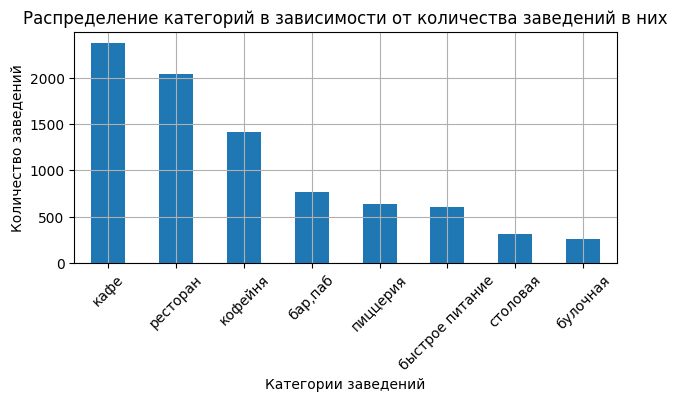

In [23]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(7, 3))

# Строим столбчатую диаграмму с помощью pandas через plot(kind='bar')
df['category'].value_counts().plot(
               kind='bar', # Тип графика - столбчатая диаграмма
               rot=45, # Градус вращения подписи по оси Х
               legend=False, # Выключаем легенду
               title=f'Распределение категорий в зависимости от количества заведений в них'
)
# Настраиваем оформление графика
plt.xlabel('Категории заведений')
plt.ylabel('Количество заведений')
# Добавляем сетку графика
plt.grid()

# Выводим график
plt.show()

Из исследования стало понятно, что наибольшее количество заведений является кафе -2378, что составляет 28 %, немного меньше рестораны-2043 (24 %)и кофейни-1413 (17%), остальные категории занимают наименьшую часть, каждая менее 10 %.

### 3.2. Исследуем административные районы города Москва и заведения в них. Отдельно уделим внимание Центральному округу Москвы и определим категории заведений в нем.

In [24]:
# Посчитаем количество уникальных заведений для каждого округа Столицы.

district_counts = df.groupby('district')['id'].nunique().sort_values(ascending=False)

# Создаем DataFrame с количествами и процентами
result = pd.DataFrame({
    'count': district_counts,
    'percentage': (district_counts / district_counts.sum() * 100).round(2)
})

print('Распределение заведений по значениям столбца district:')
print(result)

Распределение заведений по значениям столбца district:
                                         count  percentage
district                                                  
Центральный административный округ        2242       26.67
Северный административный округ            900       10.71
Южный административный округ               892       10.61
Северо-Восточный административный округ    891       10.60
Западный административный округ            851       10.12
Восточный административный округ           798        9.49
Юго-Восточный административный округ       714        8.49
Юго-Западный административный округ        709        8.43
Северо-Западный административный округ     409        4.87


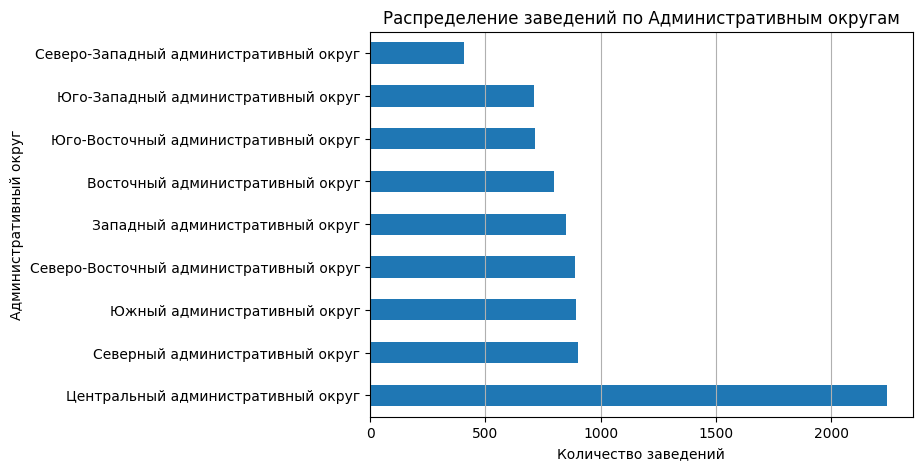

In [25]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(7, 5))

# Считаем уникальное количество заведений
district_counts = df.groupby('district')['id'].nunique().sort_values(ascending=False)

# Строим столбчатую диаграмму с помощью pandas через plot(kind='bar')
district_counts.plot(
               kind='barh', # Тип графика - столбчатая диаграмма
               legend=False, # Выключаем легенду
               title=f'Распределение заведений по Административным округам'
)
# Настраиваем оформление графика
plt.xlabel('Количество заведений')
plt.ylabel('Административный округ')
# Добавляем сетку графика
plt.grid(axis='x')  

# Выводим график
plt.show()

Из анализа видно, что наибольшее количество заведений именно в Центральном округе Москвы 2242, что составляет 27 % от общего количества. Почти треть заведений.

In [26]:
# Фильтруем данные только для центрального округа
central_district = df[df['district'] == 'Центральный административный округ']

# Группируем по категориям
district_counts = central_district.groupby('category')['id'].nunique().sort_values(ascending=False)

# Создаем DataFrame с количествами и процентами
result = pd.DataFrame({
    'count': district_counts,
    'percentage': (district_counts / district_counts.sum() * 100).round(2)
})

print('Распределение заведений по категориям в Центральном административном округе:')
print(result)

Распределение заведений по категориям в Центральном административном округе:
                 count  percentage
category                          
ресторан           670       29.88
кафе               464       20.70
кофейня            428       19.09
бар,паб            364       16.24
пиццерия           113        5.04
быстрое питание     87        3.88
столовая            66        2.94
булочная            50        2.23


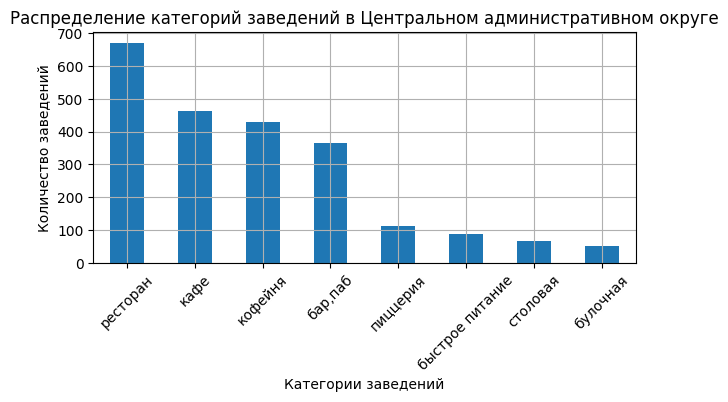

In [27]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(7, 3))

# Фильтруем данные только для Центрального административного округа
central_district = df[df['district'] == 'Центральный административный округ']

# Строим столбчатую диаграмму для отфильтрованных данных
central_district['category'].value_counts().plot(
    kind='bar',  # Тип графика - столбчатая диаграмма
    rot=45,  # Градус вращения подписи по оси Х
    legend=False,  # Выключаем легенду
    title='Распределение категорий заведений в Центральном административном округе'
)

# Настраиваем оформление графика
plt.xlabel('Категории заведений')
plt.ylabel('Количество заведений')
# Добавляем сетку графика
plt.grid()

# Выводим график
plt.show()

Из проведенного анализа видно, что в Центральном округе больше всего ресторанов -670 (30%), потом уже кафе- 464 (21%) и кофейни - 428 (19%).

### 3.3. Исследуем соотношение сетевых и не сетевых заведений и распределение их по категориям.

In [28]:
# Посчитаем количество заведений сетевых и не сетевых.
chain_counts = df.groupby('chain')['id'].nunique()

# Создаем DataFrame с количествами и процентами
result = pd.DataFrame({
    'count': chain_counts,
    'percentage': (chain_counts / chain_counts.sum() * 100).round(2)
})

print('Распределение сетевых и не сетевых заведений в Москве')
print(result)

Распределение сетевых и не сетевых заведений в Москве
       count  percentage
chain                   
0       5201       61.87
1       3205       38.13


Text(0.5, 1.0, 'Распределение количества сетевых и несетевых заведений')

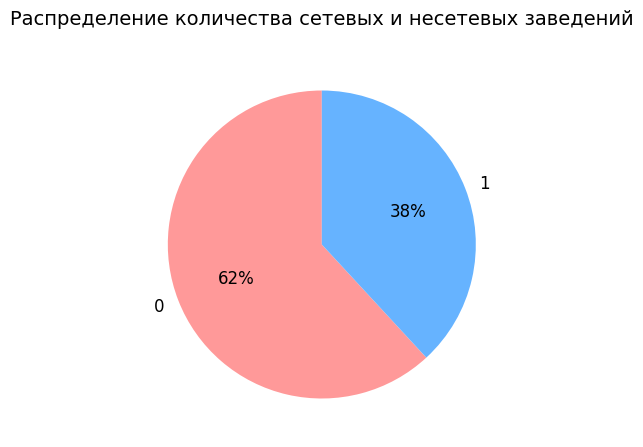

In [29]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(7, 5))

# Получаем данные для круговой диаграммы
chain_counts = df.groupby('chain')['id'].nunique()

# Строим круговую диаграмму
plt.pie(chain_counts, 
        labels=chain_counts.index,  # Подписи секторов
        autopct='%1.0f%%',          # Формат отображения процентов 
        startangle=90,              # Начальный угол поворота 
        colors=['#ff9999', '#66b3ff'],  # Цвета для секторов 
        textprops={'fontsize': 12}  # Размер шрифта для подписей
)

# Добавляем заголовок
plt.title(f'Распределение количества сетевых и несетевых заведений', fontsize=14, pad=20)


Как мы видим количество несетевых заведений значительно больше чем сетевых 62 % против 38%.

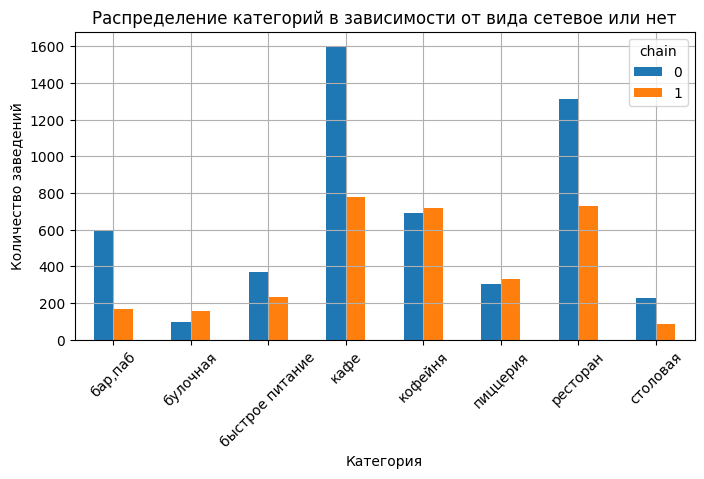

In [30]:
# Построим график столбчатой диаграммы
grouped = df.groupby('category')['chain'].value_counts().unstack(fill_value=0)
grouped.plot(kind='bar',
               title=f'Распределение категорий в зависимости от вида сетевое или нет',
               legend=True,
               ylabel='Количество заведений',
               xlabel='Категория',
               rot=45,
               figsize=(8, 4))
plt.grid()

# Выводим график
plt.show()

In [31]:
# Создаем DataFrame для таблицы
table_data = []
for category in grouped.index:
    # Столбец 1 - это сетевые (True), столбец 0 - несетевые (False)
    сетевые = grouped.loc[category, 1] if 1 in grouped.columns else 0
    несетевые = grouped.loc[category, 0] if 0 in grouped.columns else 0
    всего = сетевые + несетевые
    процент = (сетевые / всего * 100) if всего > 0 else 0
    table_data.append([category, всего, сетевые, несетевые, f'{процент:.1f}%'])

table_df = pd.DataFrame(table_data, 
                        columns=['Категория', 'Всего заведений', 'Сетевые', 'Несетевые', '% сетевых'])

# Выводим таблицу
display(table_df)

,Категория,Всего заведений,Сетевые,Несетевые,% сетевых
0,"бар,паб",765,169,596,22.1%
1,булочная,256,157,99,61.3%
2,быстрое питание,603,232,371,38.5%
3,кафе,2378,779,1599,32.8%
4,кофейня,1413,720,693,51.0%
5,пиццерия,633,330,303,52.1%
6,ресторан,2043,730,1313,35.7%
7,столовая,315,88,227,27.9%


Распределение принадлежности к сети по категориям говорить нам о том, что в категориях булочная 61%, пицерия 52% , кофейня 51% преобладает сетевая форма заведений, в остальных категориях заведений больше несетевых заведений

### 3.4. Исследуем количество посадочных мест в заведениях.

Посмотрим встречаются ли аномальные значения, или выбросы. Приведем для каждой категории заведений типичное количество мест. Визуализируем эти данные.

In [32]:
# Изучаем статистические показатели столбца seats
print('Статистические показатели столбца seats:')
df['seats'].describe(percentiles=[0.25, 0.5, 0.75, 0.95, 0.99])

Статистические показатели столбца seats:


count    4795.000000
mean      108.421689
std       122.833396
min         0.000000
25%        40.000000
50%        75.000000
75%       140.000000
95%       307.000000
99%       625.000000
max      1288.000000
Name: seats, dtype: float64

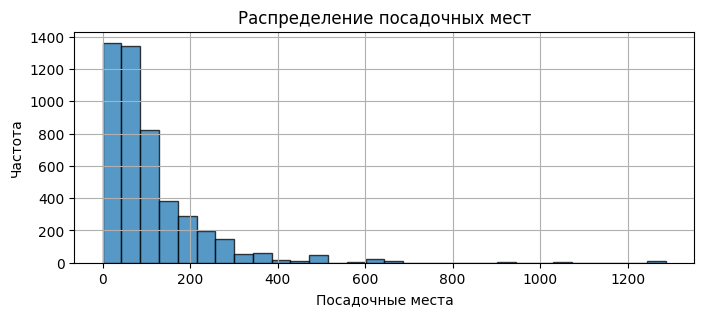

In [33]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(8, 3))

# Строим гистограмму с помощью pandas через plot(kind='hist')
df['seats'].plot(
                kind='hist', # Тип графика - гистограмма
                bins=30, # Устанавливаем количество корзин
                alpha=0.75,
                edgecolor='black',
                rot=0, # Градус вращения подписи по оси Х
)

# Настраиваем оформление графика
plt.title('Распределение посадочных мест')
plt.xlabel('Посадочные места')
plt.ylabel('Частота')
# Добавляем сетку графика
plt.grid()

# Выводим график
plt.show()

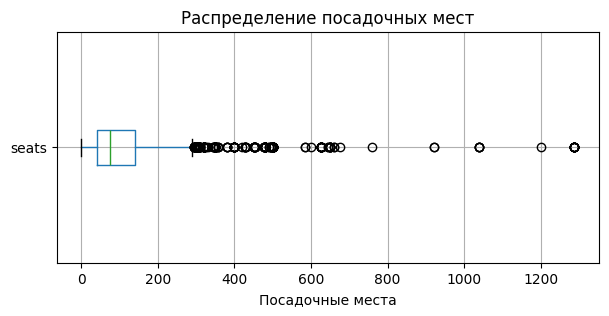

In [34]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(7, 3))

# Строим диаграмму размаха значений в столбце score
df.boxplot(column='seats', vert=False)

# Добавляем заголовок и метки оси
plt.title('Распределение посадочных мест')
plt.xlabel('Посадочные места')

# Выводим график
plt.show()

Распределение количества мест асимметричное, скошенное вправо. Минимальное количесто мест — 0, а максимальное — 1278, что является не вполне корректным. Среднее значение соответствует 108 местам, тогда как медиана — 75 мест. Среднее и медианное значение далеки друг от друга. что говорит о выбросе данных с большим количеством мест, так как 99 процентиль всего 625 мест, а максимальное значение 1278. По гистограмме размаха видно, что значения выше примерно 300 мест можно считать выбросами.

При анализе данных отбросим значения более 99 процентиля, это 625 мест. Потому что значения больше этого единичны и сильно исказят картину анализа.


In [35]:
# Находим 99-й процентиль
outliers = df['seats'].quantile(0.99)

# Отбираем данные, оставляя значения меньше найденного порога выбросов
new_df = df.copy()[df['seats'] < outliers]

# Выводим результат describe() после фильтрации данных
print(new_df['seats'].describe())


count    4742.000000
mean      100.420919
std        92.901015
min         0.000000
25%        40.000000
50%        74.000000
75%       130.000000
max       600.000000
Name: seats, dtype: float64


Ситуация немного улучшилась, среднее 100 мест и медиана 74 места приблизились друк к другу. Исключилось из выборки 53 заведения. 

In [36]:
# Посчитаем медианное количество посадочных мест для каждой категории заведений.
print('Медианное количество посадочных мест для каждой категории заведений category:')
new_df.groupby('category')['seats'].median().sort_values(ascending=False)

Медианное количество посадочных мест для каждой категории заведений category:


category
ресторан           86.0
бар,паб            80.0
кофейня            78.0
столовая           75.0
быстрое питание    65.0
кафе               60.0
пиццерия           52.0
булочная           50.0
Name: seats, dtype: float64

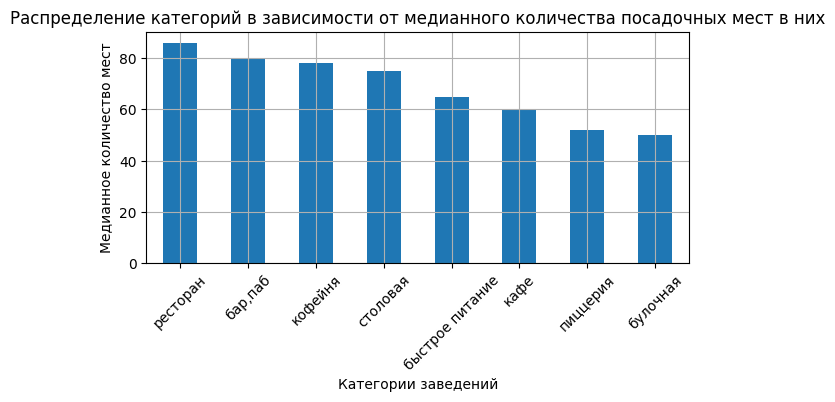

In [37]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(7, 3))

# Группируем по категориям и вычисляем медианное количество мест
median_seats_by_category = new_df.groupby('category')['seats'].median().sort_values(ascending=False)

# Строим столбчатую диаграмму с помощью pandas через plot(kind='bar')
median_seats_by_category.plot(
               kind='bar', # Тип графика - столбчатая диаграмма
               rot=45, # Градус вращения подписи по оси Х
               legend=False, # Выключаем легенду
               title=f'Распределение категорий в зависимости от медианного количества посадочных мест в них'
)
# Настраиваем оформление графика
plt.xlabel('Категории заведений')
plt.ylabel('Медианное количество мест')
# Добавляем сетку графика
plt.grid()

# Выводим график
plt.show()

Из таблицы и графика мы видим как распределяется медианное значение по количеству посадочных мест, что показвыает типичное количество мест в заведениях в зависимости от категории. 

### 3.5. Исследуем рейтинг заведений.

Распределим средние значения рейтингов по категориям заведений, посмотрим расброс значений. Построим визуализацию

In [38]:
# Общая статистика по рейтингу
print("Общая статистика по рейтингу:")
print(df['rating'].describe(percentiles=[0.01, 0.25, 0.5, 0.75,0.99]))

Общая статистика по рейтингу:
count    8406.000000
mean        4.229895
std         0.470348
min         1.000000
1%          2.300000
25%         4.100000
50%         4.300000
75%         4.400000
99%         5.000000
max         5.000000
Name: rating, dtype: float64


- Среднее значение (4.23) близко к максимуму (5.0)
- 75% заведений имеют рейтинг ≥ 4.1
- Медиана (4.3) выше среднего, что указывает на левостороннюю асимметрию
- Стандартное отклонение (0.47) относительно небольшое
- Вывод:  Данные достаточно однородны (большая часть находится в узком диапазоне 0т 4 до 5)


In [39]:
# Посчитаем средний рейтинг для каждой категории заведений.
print('Средний рейтинг для каждой категории заведений category:')
df.groupby('category')['rating'].mean().sort_values(ascending=False)

Средний рейтинг для каждой категории заведений category:


category
бар,паб            4.387712
пиццерия           4.301264
ресторан           4.290357
кофейня            4.277282
булочная           4.268359
столовая           4.211429
кафе               4.123886
быстрое питание    4.050249
Name: rating, dtype: float64

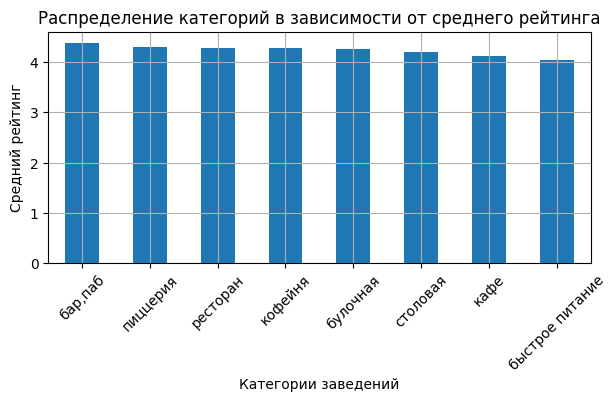

In [40]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(7, 3))

# Группируем по категориям и вычисляем средний рейтинг
avg_rating_category = df.groupby('category')['rating'].mean().sort_values(ascending=False)

# Строим столбчатую диаграмму с помощью pandas через plot(kind='bar')
avg_rating_category.plot(
               kind='bar', # Тип графика - столбчатая диаграмма
               rot=45, # Градус вращения подписи по оси Х
               legend=False, # Выключаем легенду
               title=f'Распределение категорий в зависимости от среднего рейтинга'
)
# Настраиваем оформление графика
plt.xlabel('Категории заведений')
plt.ylabel('Средний рейтинг')
# Добавляем сетку графика
plt.grid()

# Выводим график
plt.show()

Из проведенного исследования распределения рейтинга заведений в завсимости от категории видно, что расброс значений между категориями миниамальный от 4, до 4,4 балла. Поэтому сдесь трудно выделить наиболее популярные категории заведений. Наибольщий рейтинг 4,4 балла у баров(пабов).

### 3.6. Изучим кореляцию данных с рейтингом заведения

Построим матрицу кореляции рейтинга в зависимости от категории, расположения, статуса сетевого заведения, количеством мест, ценовой категорией, круглосуточностью.

In [41]:
# Создаем столбец-индикатор круглосуточной работы
df['is_24_7'] = df['hours'].str.contains('круглосуточно', case=False, na=False).astype(int)

# Вычисляем корреляционную матрицу с использованием phi_k
correlation_matrix = df[['category','district', 'chain', 'seats', 'price',
                         'is_24_7', 'rating']].phik_matrix()

# Выводим результат
print('Корреляционная матрица с коэффициентом phi_k для переменной rating')
correlation_matrix.loc[correlation_matrix.index != 'rating'][['rating']].sort_values(by='rating', ascending=False)

interval columns not set, guessing: ['chain', 'seats', 'is_24_7', 'rating']
Корреляционная матрица с коэффициентом phi_k для переменной rating


,rating
price,0.281294
district,0.200691
category,0.190003
is_24_7,0.144762
chain,0.108092
seats,0.000000


Наибольшая корреляция рейтинга заведений наблюдается с ценовой категорией (`0.29`). Для остальных признаков коэффициент корреляции снижается с `0.2` до `0`.

Важно помнить, что `phi_k` сообщает только о наличии связи между данными. На сам характер связи коэффициент `phi_k` не указывает, поэтому после получения коэффициента следует продолжить анализ. Например, можно предположить, что увеличение ценовой категории отрицательно связано с рейтингом — чем выше категория цен, тем меньше рейтинг. Такую гипотезу можно проверить при анализе данных.

Перед тем как перейти к дальнейшему анализу, визуализируем результат корреляции с помощью тепловой карты и библиотеки seaborn:

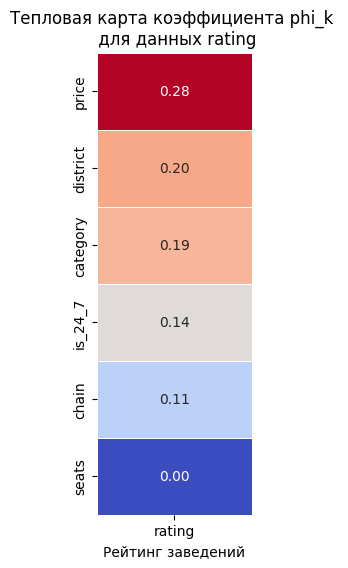

In [42]:
# Строим тепловую карту
plt.figure(figsize=(2, 6))

# Сохраняем матрицу корреляции признака rating с другими признаками заведений
data_heatmap = correlation_matrix.loc[correlation_matrix.index != 'rating'][['rating']].sort_values(by='rating', ascending=False)
sns.heatmap(data_heatmap,
            annot=True, # Отображаем численные значения в ячейках карты
            fmt='.2f', # Форматируем значения корреляции: два знака после точки
            cmap='coolwarm', # Устанавливаем цветовую гамму от красного (макс. значение) к синему
            linewidths=0.5, # Форматируем линию между ячейками карты
            cbar=False # Отключаем цветовую шкалу
           )

# Добавляем заголовок и подпись по оси Х
plt.title('Тепловая карта коэффициента phi_k \n для данных rating')
plt.xlabel('Рейтинг заведений')

# Выводим график
plt.show()

Теперь оценим зависмиость рейтинга от ценовой категории

In [43]:
# Посчитаем средний рейтинг для каждой категории цен.
print('Средний рейтинг для каждой категории цен price:')
df.groupby('price')['rating'].mean().sort_values(ascending=False)

Средний рейтинг для каждой категории цен price:


price
высокие               4.436611
выше среднего         4.386348
средние               4.297874
низкие                4.173077
цена не определена    4.166627
Name: rating, dtype: float64

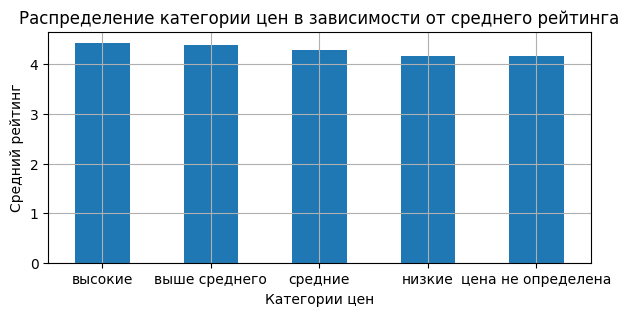

In [44]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(7, 3))

# Группируем по категори цен и вычисляем средний рейтинг
avg_rating_price = df.groupby('price')['rating'].mean().sort_values(ascending=False)

# Строим столбчатую диаграмму с помощью pandas через plot(kind='bar')
avg_rating_price.plot(
               kind='bar', # Тип графика - столбчатая диаграмма
               rot=0, # Градус вращения подписи по оси Х
               legend=False, # Выключаем легенду
               title=f'Распределение категории цен в зависимости от среднего рейтинга'
)
# Настраиваем оформление графика
plt.xlabel('Категории цен')
plt.ylabel('Средний рейтинг')
# Добавляем сетку графика
plt.grid()

# Выводим график
plt.show()

Из построеных визуализаций видим что наше предположение не подтвердилось, а наоборот заведения с более высокой ценой имеют более высокий рейтинг. Хотя разница в значениях минимальна.

### 3.7. Сгруппируем данные по названиям заведений и найдем топ-15 популярных сетей в Москве.

Для них рассчитаем значение среднего рейтинга и определелим к какой категории заведений они относятся.

In [45]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8406 entries, 0 to 8405
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 8406 non-null   object 
 1   name               8406 non-null   object 
 2   category           8406 non-null   object 
 3   address            8406 non-null   object 
 4   district           8406 non-null   object 
 5   hours              7870 non-null   object 
 6   rating             8406 non-null   float64
 7   chain              8406 non-null   int8   
 8   seats              4795 non-null   float64
 9   price              8406 non-null   object 
 10  avg_bill           3816 non-null   object 
 11  middle_avg_bill    3149 non-null   float64
 12  middle_coffee_cup  535 non-null    float64
 13  is_24_7            8406 non-null   int64  
dtypes: float64(4), int64(1), int8(1), object(8)
memory usage: 862.1+ KB


In [46]:
df.head()

,id,name,category,address,district,hours,rating,chain,seats,price,avg_bill,middle_avg_bill,middle_coffee_cup,is_24_7
0,0c3e3439a8c64ea5bf6ecd6ca6ae19f0,WoWфли,кафе,"Москва, улица Дыбенко, 7/1",Северный административный округ,"ежедневно, 10:00–22:00",5.0,0,NaN,цена не определена,NaN,NaN,NaN,0
1,045780ada3474c57a2112e505d74b633,Четыре комнаты,ресторан,"Москва, улица Дыбенко, 36, корп. 1",Северный административный округ,"ежедневно, 10:00–22:00",4.5,0,4.0,выше среднего,Средний счёт:1500–1600 ₽,1550.0,NaN,0
2,1070b6b59144425896c65889347fcff6,Хазри,кафе,"Москва, Клязьминская улица, 15",Северный административный округ,"пн-чт 11:00–02:00; пт,сб 11:00–05:00; вс 11:00...",4.6,0,45.0,средние,Средний счёт:от 1000 ₽,1000.0,NaN,0
3,03ac7cd772104f65b58b349dc59f03ee,Dormouse Coffee Shop,кофейня,"Москва, улица Маршала Федоренко, 12",Северный административный округ,"ежедневно, 09:00–22:00",5.0,0,NaN,цена не определена,Цена чашки капучино:155–185 ₽,NaN,170.0,0
4,a163aada139c4c7f87b0b1c0b466a50f,Иль Марко,пиццерия,"Москва, Правобережная улица, 1Б",Северный административный округ,"ежедневно, 10:00–22:00",5.0,1,148.0,средние,Средний счёт:400–600 ₽,500.0,NaN,0


In [47]:

# Фильтруем только сетевые заведения
chain_df = df[df['chain'] == True].copy()

# Получаем топ-15 сетей по количеству заведений
top_15_names = chain_df['name'].value_counts().head(15).index.tolist()

# Фильтруем данные 
top_chains_data = chain_df[chain_df['name'].isin(top_15_names)]

# Группируем и считаем средний рейтинг
top_chains_rating = top_chains_data.groupby('name')['rating'].mean().round(2).reset_index()
top_chains_rating.columns = ['name', 'avg_rating']

# Добавляем количество филиалов
branch_counts = chain_df['name'].value_counts().head(15).reset_index()
branch_counts.columns = ['name', 'branch_count']
top_chains_rating = top_chains_rating.merge(branch_counts, on='name')

# Сортируем по количеству филиалов
top_chains_rating = top_chains_rating.sort_values('branch_count', ascending=False)

# Выводим результат
print("Топ-15 сетей с количеством филиалов и средним рейтингом:")
print(top_chains_rating.to_string(index=False))




Топ-15 сетей с количеством филиалов и средним рейтингом:
                               name  avg_rating  branch_count
                        Шоколадница        4.18           120
                     Домино'с Пицца        4.17            76
                         Додо Пицца        4.29            74
                   One Price Coffee        4.06            71
                       Яндекс Лавка        3.87            69
                              Cofix        4.08            65
                              Prime        4.12            50
                         Хинкальная        4.32            44
                           КОФЕПОРТ        4.15            42
Кулинарная лавка братьев Караваевых        4.39            39
                            Теремок        4.12            38
                            Чайхана        3.92            37
                           CofeFest        3.98            32
                            Буханка        4.40            32
             

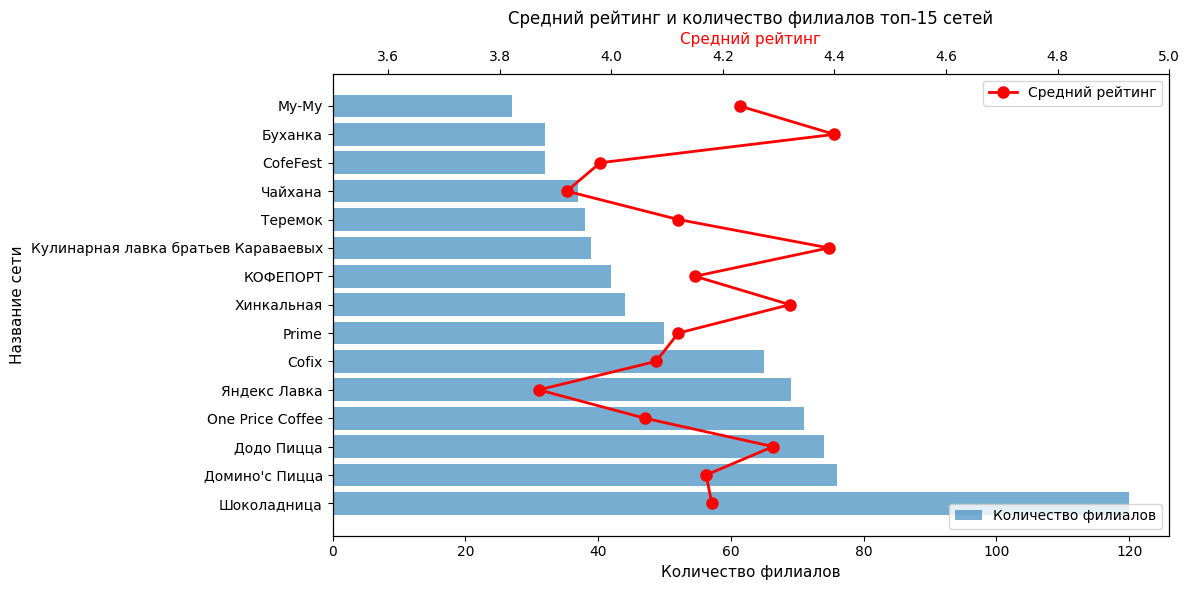

In [48]:
# Сортируем по количеству филиалов
top_chains_rating = top_chains_rating.sort_values('branch_count', ascending=False)

# Задаем размер графика
fig, ax1 = plt.subplots(figsize=(12, 6))

# Столбцы: количество филиалов
bars = ax1.barh(top_chains_rating['name'], 
                top_chains_rating['branch_count'], 
                alpha=0.6,
                label='Количество филиалов')
ax1.set_xlabel('Количество филиалов', fontsize=11)
ax1.set_ylabel('Название сети', fontsize=11)
ax1.set_title('Средний рейтинг и количество филиалов топ-15 сетей')
              
# Вторая ось для рейтинга
ax2 = ax1.twiny()
ax2.plot(top_chains_rating['avg_rating'], 
         top_chains_rating['name'], 
         'ro-', 
         linewidth=2, 
         markersize=8,
         label='Средний рейтинг')
ax2.set_xlabel('Средний рейтинг', fontsize=11, color='red')
ax2.set_xlim(3.5, 5.0)

# Легенды
ax1.legend(loc='lower right')
ax2.legend(loc='upper right')

plt.tight_layout()
plt.show()

Из проведенного исследования можносделать следующие выводы: Среди сетевых заведений самыми популярными является Шоколадница -120 филиал, с рейтингом 4,18.  В отстающих Му-МУ - 27 филиалов, но его рейтинг- 4,23. Самый высокий рейтинг у Буханки - 4,4, но количество филиалов всего - 32.

In [49]:
# Считаем сумму по категориям (количество заведений каждой категории среди топ-15 сетей)
category_distribution = top_chains_data['category'].value_counts().reset_index()
category_distribution.columns = ['category', 'count']

# Добавляем процентное соотношение
category_distribution['percentage'] = (category_distribution['count'] / category_distribution['count'].sum() * 100).round(1)

# Сортируем по убыванию
category_distribution = category_distribution.sort_values('count', ascending=False)

# Выводим результат
print("Распределение заведений топ-15 сетей по категориям:")
print(category_distribution.to_string(index=False))

Распределение заведений топ-15 сетей по категориям:
       category  count  percentage
        кофейня    336        41.2
       ресторан    186        22.8
       пиццерия    151        18.5
           кафе    100        12.3
       булочная     25         3.1
быстрое питание     12         1.5
        бар,паб      4         0.5
       столовая      2         0.2


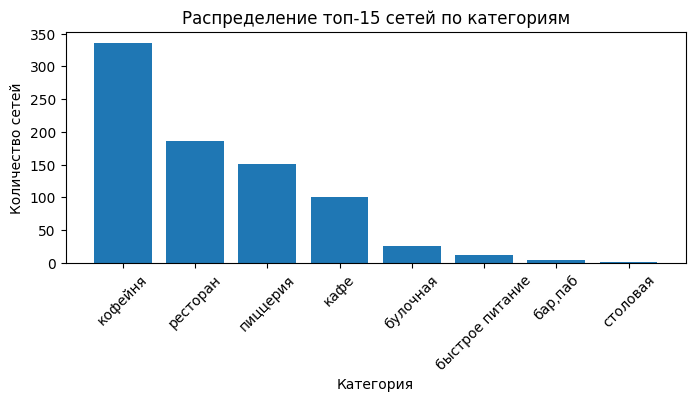

In [50]:

# Столбчатая диаграмма для распределия сетей по категориям заведений
plt.figure(figsize=(8, 3))
plt.bar(category_distribution['category'], category_distribution['count'])
plt.xlabel('Категория')
plt.ylabel('Количество сетей')
plt.title('Распределение топ-15 сетей по категориям')
plt.xticks(rotation=45)
plt.show()

По категориям самыми популярными заведениями считаются кофейни -41 %,  с большим отставанием идут рестораны- 23% , пицерии- 19 %  Наименьшее количество в категории бары(пабы) и столовые - менее 1 процента.

### 3.8. Изучим вариацию среднего чека заведений в зависимости от районов Москвы.

Проанализируем цены в Центральном округе и остальных, посмотрим как удаленность влияет на цену.

In [51]:
# Посчитаем средную цену для каждого округа Москвы.
print('Средняя цена для каждого округа Москвы district:')
df.groupby('district')['middle_avg_bill'].mean().sort_values(ascending=False)

Средняя цена для каждого округа Москвы district:


district
Центральный административный округ         1191.057547
Западный административный округ            1053.225490
Северный административный округ             927.959627
Южный административный округ                834.398089
Северо-Западный административный округ      822.222930
Восточный административный округ            820.626923
Юго-Западный административный округ         792.561702
Северо-Восточный административный округ     716.611296
Юго-Восточный административный округ        654.097938
Name: middle_avg_bill, dtype: float64

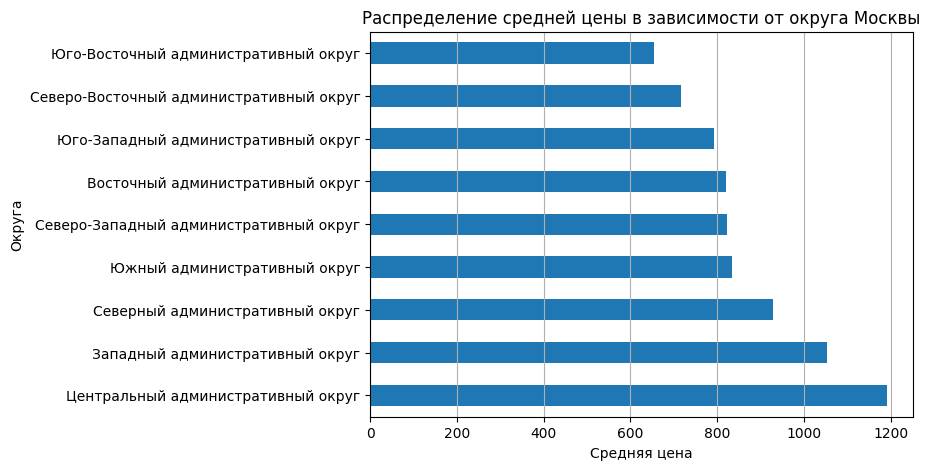

In [52]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(7, 5))

# Группируем по округу и вычисляем средную цену
avg_price = df.groupby('district')['middle_avg_bill'].mean().sort_values(ascending=False)

# Строим горизонтальную столбчатую диаграмму 
avg_price.plot(
               kind='barh',  
               legend=False, # Выключаем легенду
               title=f'Распределение средней цены в зависимости от округа Москвы'
)
# Настраиваем оформление графика
plt.xlabel('Средняя цена')  
plt.ylabel('Округа')       
# Добавляем сетку графика
plt.grid(axis='x')  

# Выводим график
plt.show()

Так как административные округа Москвы распределены географически по кругу, а в центре -Ценральный административный округ, то судить об удаленности того или иного округа от центра не корректно. Из провенного исследования видим , что в Ценральном административном округе средньняя цена наибольшая и составляет примерно 1191 рубль. В остальных округах цены ниже, наименьшая в Юго- Восточном это 654 рубля. Наибольшая в Западном округе. - 1053 рублея.

### 3.9. Промежуточные выводы после исследования.

В результате проведенных исследовний мы выяснили какие категории заведений имеются и их количество, получилось 8 категорий, самая популярная кафе-2378 заведений, что составляет 28 %. 
- Выяснили сколько административных округов представлено в данных их 9, больше всего заведений в Центральном округе 2242 это 27 %, его мы изучили более детально и выяснили, что больше всего в нем ресторанов -670 (30%). 
- Среди сетевых и не сетевых форм преобладает не сетевая с количеством заведений 5201 (62%) против 3205 (38%) сетевых . Среди сетевых наболее популярны категории: булочная 61%, пицерия 52% , кофейня 51% заведений. 
- Исследовав количество посадочных мест в заведениях нашли нетипичные значения в диапазоне более 600 мест и отфильтровали данные до 600 мест. Наиболщее количество мест в ресторанах.
- По рейтингу разница между категориями очень мала, тем неменее заведения выстроились следующим образом: верхние строчки занимают бары(пабы), пицерии и рестораны.
- Изучая взаимосвязь данных выяснили что самая большая кореляция между рейтингом и категорией цен, изучив ее более подробно пришли к выводу что, найбольший рейтинг у заведений с наибольшей ценовой категорией.
- Нашли топ 15 самых популярных сетей в Москве, первую строчку занимает сеть Шоколадница -120 филиалов со средним рейтингом 4,18. Найбольший рейтинг имет сеть Буханка - 4,4 состоит из 32 филиалов. 
- Как и ожидалось самые высокие цены в Центральном округе Москвы, в остальных округах они тоже отличаются и самым "дорогим" после центрального является Западный административный округ. 

---


## Итоговый вывод и рекомендации

В ходе исследования было проанализировано 8406 заведенй общественного питания Москвы. Хотя данные и были не полными, потому-что взяты из открытых источников, они включали в себя названия, адреса, месторасположение (административный округ), категорию, время работы, рейтинг, принадлежность к сети, количество посадочных мест, категории цен, средние цены. Основной акцент исследования был сделан на изучение популярности заведений по их категориям и месту расположения в городе Москва.
### Наиболее популярные заведения
Из общего количества заведений 8406, самые популярные  это кафе их в Москве 2378, что сотавляет 28 % от всех заведений . В Центральном округе больше всего заведений питания 2242 и в них преобладают рестраны 670 - 30% . Эти категории заведений в большей своей части яваляются не сетевыми. Рейтинг имеют примерно одинаковый. Если посмотреть на заведения принадлежащие к сети, то среди них самые популярные Шоколадница имеет 120 филиалов и принадлежит к самой популярной категории среди сетевых -кофейня. Рейтинг у нее 4,18.
### Рекомендации
Основная цель нашего исследования проанализировать данные заведений общественного питания и дать рекомендации закакзчику по вариантам открытия собственного бизнеса в этой сфере. Исходя из этого можем предположить некотрые варианты:
1. Если заведение будет не сетевым, то наилучшим вариантом мы видим в Центральном округе это ресторан, в остальной части Москвы кафе.
2. Если заведения будет принадлежать к сети, то возможно это будет  кофейня Шоколадница, они самые популярные.
- Многое будет зависеть от стартовых возможностей закзчика.